# Model-Based RL: Learned World Models

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand model-based RL
- Learn world models from experience
- Use learned models for planning
- Compare model-based vs model-free

## 🔗 Prerequisites

- ✅ Understanding of RL fundamentals
- ✅ Understanding of neural networks
- ✅ Python, NumPy knowledge

---

## Official Structure Reference

This notebook covers practical activities from **Course 09, Unit 5**:
- Building model-based RL systems with learned world models

---

## Introduction

**Model-based RL** learns a model of the environment dynamics and uses it for planning, potentially achieving higher sample efficiency than model-free methods.

## Lesson Brief

This lesson introduces model-based RL, where the agent tries to learn how the environment works and then plan with that knowledge.

Students will see the full idea in simple form: collect experience, build a model, then use the model to choose actions.

Why this matters: model-based RL explains why some agents can learn faster from fewer environment interactions.

It also prepares students to think critically about model errors.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## Recommended YouTube Video

To reinforce this lesson, watch **Yannic Kilcher - "Dreamer v2: Mastering Atari with Discrete World Models"**:
[Watch on YouTube](https://www.youtube.com/watch?v=o75ybZ-6Uu8)

Why this pick:
- strong paper-explainer style.
- Shows how world models support imagination-based learning and sample efficiency.
- Good match for students meeting model-based RL through modern world-model examples.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- World model: a learned model of environment behavior.
- Planning: reasoning before acting.
- Prediction error: model expectation versus reality.
- Imagined rollout: simulated future steps.
- Compounding error: small model mistakes that grow over many simulated steps.

### Quick Check
- What do we gain by learning a model?
- How can planning save real interaction?
- What risk comes from an inaccurate model?
- Why can long imagined rollouts become unreliable?

### Common Mistakes
- Thinking the model must be perfect.
- Ignoring accumulated model error.
- Confusing modeling the world with learning the policy.
- Assuming simulated planning is automatically trustworthy just because it is fast.


## Faster Learning Comes with a New Risk

Model-based RL is attractive because it can reuse experience more efficiently.
But the benefit comes with a new failure mode.

### The promise

If the agent learns a useful model of the world, it can plan in imagination instead of requiring every trial in the real environment.
That can greatly improve sample efficiency.

### The risk

If the model is wrong, planning can become confidently wrong too.
A small prediction error may not matter for one step, but over many imagined steps the error can accumulate.

### Teaching takeaway

Students should leave this notebook with both ideas together:

- model-based RL can learn faster
- model error can poison planning if we trust it too much

The point is not to worship sample efficiency alone.

## Inputs and Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [1]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np

# Show text or numbers in the cell output area under the code.
print("✅ Libraries imported!")
# Show text or numbers in the cell output area under the code.
print("\nModel-Based RL: Learned World Models")
# Show text or numbers in the cell output area under the code.
print("=" * 60)

# Show text or numbers in the cell output area under the code.
print("\nModel-Based RL:")
# Show text or numbers in the cell output area under the code.
print("  - Learn: Transition model P(s'|s,a) and reward model R(s,a)")
# Show text or numbers in the cell output area under the code.
print("  - Plan: Use model to simulate and plan")
# Show text or numbers in the cell output area under the code.
print("  - Act: Execute planned actions")

# Show text or numbers in the cell output area under the code.
print("\nWorld Model Learning:")
# Show text or numbers in the cell output area under the code.
print("  - Supervised learning from (s,a,s',r) tuples")
# Show text or numbers in the cell output area under the code.
print("  - Neural networks to approximate dynamics")
# Show text or numbers in the cell output area under the code.
print("  - Predictive models for next states/rewards")

# Show text or numbers in the cell output area under the code.
print("\nBenefits:")
# Show text or numbers in the cell output area under the code.
print("  - Higher sample efficiency")
# Show text or numbers in the cell output area under the code.
print("  - Planning capabilities")
# Show text or numbers in the cell output area under the code.
print("  - Better exploration")

# Show text or numbers in the cell output area under the code.
print("\n✅ Model-based RL concepts understood!")


✅ Libraries imported!

Model-Based RL: Learned World Models

Model-Based RL:
  - Learn: Transition model P(s'|s,a) and reward model R(s,a)
  - Plan: Use model to simulate and plan
  - Act: Execute planned actions

World Model Learning:
  - Supervised learning from (s,a,s',r) tuples
  - Neural networks to approximate dynamics
  - Predictive models for next states/rewards

Benefits:
  - Higher sample efficiency
  - Planning capabilities
  - Better exploration

✅ Model-based RL concepts understood!


## Worked Example: Learn a Small World Model, Then Plan

In model-based RL, the agent tries to answer this question:

`If I take action a in state s, what will probably happen next?`

Below, the agent explores a tiny 1D environment, collects transitions, builds a
simple empirical model, and then uses that model to plan a path to the goal.

This is not a full modern world-model system, but it captures the core idea:
**experience -> model -> planning**.

### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [2]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np

# Use NumPy for fast numeric arrays and math on grids of numbers.
np.random.seed(42)
# Total number of states = rows * columns (flattened indices 0..N-1).
N_STATES = 6
# Save a value in a name so the next lines can read it.
GOAL = N_STATES - 1
# Create the list of action names (their indices are the numeric action ids).
ACTIONS = ["left", "right"]


# Function `true_step` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: state, action.
def true_step(state, action):
    # If the condition is True, run the indented block under this line.
    if action == "right":
        # Unpack the one-step model output from transition(state, action).
        next_state = min(state + 1, GOAL)
    # Else: run this block when none of the if/elif tests above matched.
    else:
        # Unpack the one-step model output from transition(state, action).
        next_state = max(state - 1, 0)
    # Unpack the one-step model output from transition(state, action).
    reward = 1.0 if next_state == GOAL else -0.1
    # Send a value back to whoever called this function.
    return next_state, reward


# Collect experience from random exploration.
# Save a value in a name so the next lines can read it.
transition_counts = {}
# Unpack the one-step model output from transition(state, action).
reward_sums = {}
# Start a loop: repeat the indented block once per item in the sequence.
for _ in range(200):
    # Create or choose a variable used in the Bellman warm-up demo.
    state = np.random.randint(0, N_STATES)
    # Save a value in a name so the next lines can read it.
    action = np.random.choice(ACTIONS)
    # Unpack the one-step model output from transition(state, action).
    next_state, reward = true_step(state, action)
    # Save a value in a name so the next lines can read it.
    transition_counts[(state, action, next_state)] = transition_counts.get((state, action, next_state), 0) + 1
    # Unpack the one-step model output from transition(state, action).
    reward_sums[(state, action)] = reward_sums.get((state, action), 0.0) + reward


# Build a simple empirical model.
# Save a value in a name so the next lines can read it.
model_next_state = {}
# Another assignment—same idea: store a value for the lines below.
model_reward = {}
# Start a loop: repeat the indented block once per item in the sequence.
for state in range(N_STATES):
    # Start a loop: repeat the indented block once per item in the sequence.
    for action in ACTIONS:
        # Save a value in a name so the next lines can read it.
        candidates = {
            # Execute: ns: count
            ns: count
            # Start a loop: repeat the indented block once per item in the sequence.
            for (s, a, ns), count in transition_counts.items()
            # If the condition is True, run the indented block under this line.
            if s == state and a == action
        # Part of a dict/set literal layout (syntax grouping).
        }
        # If the condition is True, run the indented block under this line.
        if not candidates:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Save a value in a name so the next lines can read it.
        best_next = max(candidates, key=candidates.get)
        # Another assignment—same idea: store a value for the lines below.
        total_visits = sum(candidates.values())
        # Another assignment—same idea: store a value for the lines below.
        model_next_state[(state, action)] = best_next
        # Another assignment—same idea: store a value for the lines below.
        model_reward[(state, action)] = reward_sums[(state, action)] / total_visits


# Plan with the learned model by preferring actions that move closer to the goal.
# Function `plan_with_model` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: start_state.
def plan_with_model(start_state):
    # Create or choose a variable used in the Bellman warm-up demo.
    state = start_state
    # Save a value in a name so the next lines can read it.
    trajectory = [state]
    # Another assignment—same idea: store a value for the lines below.
    chosen_actions = []
    # Another assignment—same idea: store a value for the lines below.
    total_reward = 0.0
    # Start a loop: repeat the indented block while the condition stays True.
    while state != GOAL:
        # Save a value in a name so the next lines can read it.
        candidates = []
        # Start a loop: repeat the indented block once per item in the sequence.
        for action in ACTIONS:
            # Unpack the one-step model output from transition(state, action).
            next_state = model_next_state.get((state, action), state)
            # Save a value in a name so the next lines can read it.
            predicted_reward = model_reward.get((state, action), -999)
            # Another assignment—same idea: store a value for the lines below.
            distance_to_goal = abs(GOAL - next_state)
            # Add one new item to the end of a list (the list grows in place).
            candidates.append((distance_to_goal, -predicted_reward, action, next_state))
        # Save a value in a name so the next lines can read it.
        _, _, action, next_state = min(candidates)
        # Add one new item to the end of a list (the list grows in place).
        chosen_actions.append(action)
        # Save a value in a name so the next lines can read it.
        total_reward += model_reward[(state, action)]
        # Create or choose a variable used in the Bellman warm-up demo.
        state = next_state
        # Add one new item to the end of a list (the list grows in place).
        trajectory.append(state)
        # If the condition is True, run the indented block under this line.
        if len(trajectory) > 10:
            # Stop the loop completely and continue after the loop block.
            break
    # Send a value back to whoever called this function.
    return trajectory, chosen_actions, total_reward


# Save a value in a name so the next lines can read it.
trajectory, chosen_actions, predicted_return = plan_with_model(start_state=0)

# Show text or numbers in the cell output area under the code.
print("Learned model examples:")
# Start a loop: repeat the indented block once per item in the sequence.
for key in sorted(model_next_state)[:6]:
    # Show text or numbers in the cell output area under the code.
    print(f"  {key} -> next_state={model_next_state[key]}, reward={model_reward[key]:.2f}")

# Show text or numbers in the cell output area under the code.
print("\nPlanned actions from state 0:", chosen_actions)
# Show text or numbers in the cell output area under the code.
print("Planned trajectory from state 0:", trajectory)
# Show text or numbers in the cell output area under the code.
print("Predicted return along planned path:", round(predicted_return, 2))

# Show text or numbers in the cell output area under the code.
print("\nTeaching point:")
# Show text or numbers in the cell output area under the code.
print("The agent first learns an approximate model of transitions and rewards, then")
# Show text or numbers in the cell output area under the code.
print("uses that learned model to choose a sequence of actions that should move toward the goal.")


Learned model examples:
  (0, 'left') -> next_state=0, reward=-0.10
  (0, 'right') -> next_state=1, reward=-0.10
  (1, 'left') -> next_state=0, reward=-0.10
  (1, 'right') -> next_state=2, reward=-0.10
  (2, 'left') -> next_state=1, reward=-0.10
  (2, 'right') -> next_state=3, reward=-0.10

Planned actions from state 0: ['right', 'right', 'right', 'right', 'right']
Planned trajectory from state 0: [0, 1, 2, 3, 4, 5]
Predicted return along planned path: 0.6

Teaching point:
The agent first learns an approximate model of transitions and rewards, then
uses that learned model to choose a sequence of actions that should move toward the goal.


In [3]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References & Further Reading

### Books
- Sutton & Barto — [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html) (free online, the RL bible)

### Papers
- Mnih et al. (2015) — [Human-level control through deep RL (DQN)](https://www.nature.com/articles/nature14236)
- Silver et al. (2016) — [AlphaGo](https://www.nature.com/articles/nature16961)

### State-of-the-art OpenAI Five beat world champions in Dota2; AlphaFold uses RL-like optimization for protein folding.
"""))


## 📚 References & Further Reading

### Books
- Sutton & Barto — [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html) (free online, the RL bible)

### Papers
- Mnih et al. (2015) — [Human-level control through deep RL (DQN)](https://www.nature.com/articles/nature14236)
- Silver et al. (2016) — [AlphaGo](https://www.nature.com/articles/nature16961)

### State-of-the-art OpenAI Five beat world champions in Dota2; AlphaFold uses RL-like optimization for protein folding.


## Summary

This notebook focused on the core loop of model-based RL:

- collect experience from the environment
- learn an approximate transition and reward model
- plan actions using that learned model

### Main takeaway

Model-based RL can be attractive when environment interaction is expensive,
because the agent can reuse its model for planning instead of learning only from
real experience.

### Limitation to remember

If the learned model is wrong, planning can become confidently wrong too.
That is one of the main risks of model-based approaches.

### Step Guide

**What this cell does:** Try to auto-plot lesson numbers already in memory (optional recap charts).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Either one or more plots, or a short message that nothing was auto-plotted.

**If you feel lost:** Re-run the main lesson cells so numeric variables exist, then try this recap again.


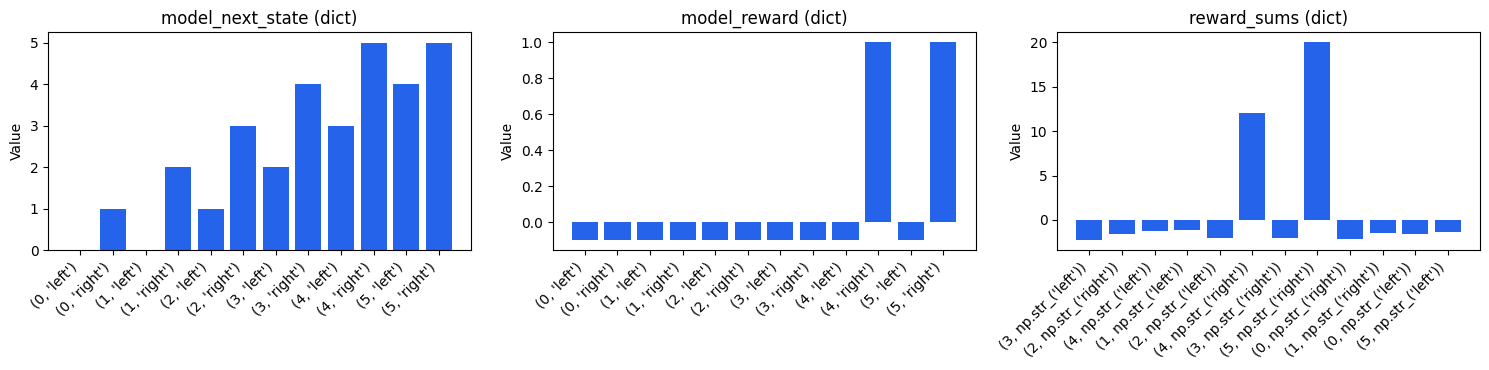

In [4]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Load a library so you can use its ready-made functions and types below.
import numbers
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Send a value back to whoever called this function.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # If the condition is True, run the indented block under this line.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Send a value back to whoever called this function.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for item in value.values():
        # If the condition is True, run the indented block under this line.
        if not _is_number(item):
            # Send a value back to whoever called this function.
            return None
        # Add one new item to the end of a list (the list grows in place).
        converted.append(float(item))
    # Send a value back to whoever called this function.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if array.ndim != dims:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 1 and not (2 <= array.size <= 200):
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 2 and array.size > 400:
        # Send a value back to whoever called this function.
        return None
    # Send a value back to whoever called this function.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math", "Figure", "fig"}
# Save a value in a name so the next lines can read it.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Start a loop: repeat the indented block once per item in the sequence.
for name in search_space:
    # If the condition is True, run the indented block under this line.
    if name in seen or name not in globals() or name in skip_names:
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # If the condition is True, run the indented block under this line.
    if dict_payload is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("dict", name, dict_payload))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # If the condition is True, run the indented block under this line.
    if array_2d is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("heatmap", name, array_2d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # If the condition is True, run the indented block under this line.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        # Skip misleading line plots for last-step env vectors (not time series).
        # If the condition is True, run the indented block under this line.
        if name in {"obs", "next_obs", "state", "action"} and array_1d.size <= 16:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("line", name, array_1d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break

# If the condition is True, run the indented block under this line.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "functions": sum(callable(value) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_title("Notebook artifact summary")
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_ylabel("Count")
    # Start a loop: repeat the indented block once per item in the sequence.
    for idx, value in enumerate(summary.values()):
        # Same plot panel as the line above—one more small plotting tweak.
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()
# Else: run this block when none of the if/elif tests above matched.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # If the condition is True, run the indented block under this line.
    if len(candidates) == 1:
        # Save a value in a name so the next lines can read it.
        axes = [axes]

    # Start a loop: repeat the indented block once per item in the sequence.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # If the condition is True, run the indented block under this line.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
            ax.bar(range(len(values)), values, color="#2563eb")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticks(range(len(values)))
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (dict)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else-if: only checked when the earlier if/elif tests were False.
        elif kind == "line":
            # Same plot panel as the line above—one more small plotting tweak.
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (series)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xlabel("Index")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (heatmap)")
            # Change something about the whole figure (not just one small subplot).
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** Model-based RL learns or uses environment dynamics so the agent can simulate consequences before acting.

**If students remember one idea:** Planning becomes possible when the agent has a workable model of how actions change the world.

**Quick check before moving on:**
- Can you explain the difference between acting from experience only and acting with a learned model?
- Can you describe one advantage and one risk of relying on a world model?

**Bridge to the next step:** This makes it easier to compare model-based and model-free RL directly in the next lesson.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## Motion recap (optional)

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


objc[41876]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x110644138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x110b409c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[41876]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x110644188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x110b40a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[41876]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x110643c88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x110b40a68). T

Motion recap | return=0.0 | frames=16 | term=True | trunc=False


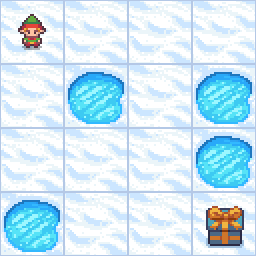

In [5]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
import course09_step_viz as cs9viz


def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
